# Evaluation


- Model Evaluation

- Application Example: A Text Classification Pipeline

- More Hyperparameter Optimization

- AutoML

## Model Evaluation
    
- Machine Learning models are evaluated by comparing the predictions $f(x)=\hat{y}$ and the target values $y$


- Useful Metrics
    - Regression (for continuous predictions - covered later)
    - Classification
    

- As ML models can memorize any training data set, **all metrics must always be computed using cross-validation**

## Classification Metrics

- Accuracy
- Precision
- Recall
- F1

### Accuracy

Defined as 

$\frac{\text{number of correct assignments}}{\text{number of data points}}$

Problem: Imbalanced classes

In [2]:
from sklearn.metrics import accuracy_score
y_true = [1,0,1,1]
y_predicted = [1,1,1,1]
accuracy_score(y_true,y_predicted)

0.75

### Precision

$${\text{precision}}={\frac {|\{{\text{relevant instances}}\}\cap \{{\text{predicted instances}}\}|}{|\{{\text{predicted instances}}\}|}}$$


In [11]:
from sklearn.metrics import precision_score
y_true = [1,0,1,1]
y_predicted = [1,1,0,0]
precision_score(y_true,y_predicted)

0.5

### Precision for Multiclass Problems

* Precision is only defined for **binary classification**

* For multiclass problems, the binary precision scores need to be averaged:
 * *micro* average: Count TP and FN across all classes, then compute precision
 * *macro* average: Compute precision for each class, then average
 * *class-frequency weighted* average: Compute precision weight single class precision by the class frequency, them average them

In [12]:
y_true = [1,0,1,2,3]
y_predicted = [1,1,1,0,1]
print(f"Micro-Average: {precision_score(y_true,y_predicted, average='micro', zero_division=0)}")
print(f"Macro-Average: {precision_score(y_true,y_predicted, average='macro', zero_division=0)}")
print(f"Class-frequency weighted: {precision_score(y_true,y_predicted,average='weighted', zero_division=0)}")

Micro-Average: 0.4
Macro-Average: 0.125
Class-frequency weighted: 0.2


### Recall


$${\text{recall}}={\frac {|\{{\text{relevant instances}}\}\cap \{{\text{predicted instances}}\}|}{|\{{\text{relevant instances}}\}|}}$$


In [13]:
from sklearn.metrics import recall_score
y_true = [1,0,1,1]
y_predicted = [1,1,0,0]
recall_score(y_true,y_predicted)

0.3333333333333333

### F1 Score

$$F=2\cdot {\frac {\mathrm {precision} \cdot \mathrm {recall} }{\mathrm {precision} +\mathrm {recall} }}$$

In [14]:
from sklearn.metrics import f1_score
y_true = [1,0,1,1]
y_predicted = [1,1,0,0]
f1_score(y_true,y_predicted)

0.4

### Precision and Recall
<center>
<img src="figures/Precisionrecall.png" width=300px>
</center>

Source Wikipedia page on [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall)

## ML Pipeline Example: Political bias prediction

- Data: [parliament speeches in German Bundestag](https://github.com/Datenschule/plpr-scraper)
- Big thanks to Knut Perseke and Friedrich Lindenberg!

In [29]:
import os, gzip
import pandas as pd
import numpy as np
import urllib.request

import warnings
warnings.filterwarnings('ignore')

DATADIR = "data"

if not os.path.exists(DATADIR): 
    os.mkdir(DATADIR)

file_name = os.path.join(DATADIR, 'bundestags_parlamentsprotokolle.csv.gzip')
if not os.path.exists(file_name):
    url_data = 'https://www.dropbox.com/s/1nlbfehnrwwa2zj/bundestags_parlamentsprotokolle.csv.gzip?dl=1'
    urllib.request.urlretrieve(url_data, file_name)

df = pd.read_csv(gzip.open(file_name), index_col=0).sample(frac=1)


alle_sprecher = df.sprecher.unique()
parteien = df.partei.unique()
partei_farben = {'cducsu':'black', 'linke':'purple', 'spd':'red', 'gruene':'green', 'fdp':'yellow'}

In [16]:
df[:5]

,sitzung,wahlperiode,sprecher,text,partei
23090,247,17,Erich G. Fritz,"Wir haben jetzt die Chance, an dieser Stelle B...",cducsu
24770,17,18,Dr. Roy Kühne,"Vielen Dank, Frau Präsidentin. – Sehr geehrte ...",cducsu
21628,237,17,Markus Kurth,"Es zählt zu den Grundsätzen des Sozialstaats, ...",gruene
4313,58,17,Klaus-Peter Willsch,"Jeder muss wissen, dass das, was an Zahlengerü...",cducsu
42321,229,18,Peter Stein,Dafür brauchen wir eine Definition. Wir haben ...,cducsu


### Imports for BoW + Linear Classifier ML Pipeline

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline

### Setting up a BoW + Linear Classifier ML Pipeline

In [18]:
def train(texts, party, num_words=1e5):
    '''
    A function that takes trains a simple NLP text classification pipeline

    Input: 
        texts and labels and number of features

    Output: 
        trained pipeline
    
    '''
    stopwords = [w.strip() for w in open("data/stopwords.txt").readlines()]
    
    clf = Pipeline([('vect', TfidfVectorizer(stop_words=stopwords, 
                                             max_features=int(num_words),
                                             ngram_range=(1,1))),
                            ('clf', SGDClassifier(loss='log_loss', alpha=1e-5))])
    clf.fit(texts, party)

    return clf



### Training a Linear Classifier

In [19]:
# Put some data aside for model evaluation
speeches, party = df.loc[df.wahlperiode==17,'text'], df.loc[df.wahlperiode==17,'partei']
train_data, test_data, train_labels, test_labels = train_test_split(speeches,party, test_size=0.2)

# Now we train on the training split
clf = train(train_data, train_labels)

### Evaluation on Training Data

In [20]:
from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve
train_predictions = clf.predict(train_data)
print(classification_report(train_predictions, train_labels))

              precision    recall  f1-score   support

      cducsu       1.00      0.97      0.98      6312
         fdp       0.96      1.00      0.98      2600
      gruene       0.98      1.00      0.99      2451
       linke       0.99      1.00      0.99      2549
         spd       0.99      0.99      0.99      5004

    accuracy                           0.99     18916
   macro avg       0.98      0.99      0.99     18916
weighted avg       0.99      0.99      0.99     18916



### Precision Recall Curves

You can set the threshold of a classifier high to achieve high precision.

This means that your classifier in some cases will not make a prediction.

So the tradeoff is that you will have low recall. 

Finding the right trade off is easy when you look at the precision-recall curve.

In [36]:
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
%matplotlib inline

def plot_pr(data, labels, clf):

    scores = clf.predict_proba(data)
    parties = clf.steps[1][1].classes_
    labels_binarized = label_binarize(labels, classes=parties)

    for idx, party in enumerate(parties):
        precision, recall, _ = precision_recall_curve(labels_binarized[:, idx], scores[:,idx])
        plt.plot(recall, precision)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(parties)

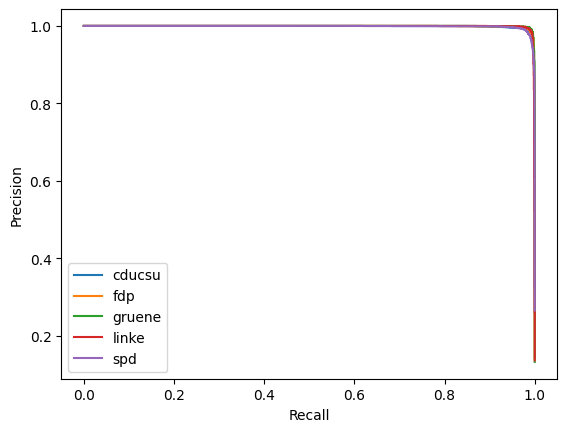

In [22]:
plot_pr(train_data, train_labels, clf)


### Evaluation on Test Data: Overfitting!

In [23]:
test_predictions = clf.predict(test_data)
print(classification_report(test_predictions, test_labels))

              precision    recall  f1-score   support

      cducsu       0.77      0.54      0.64      2137
         fdp       0.27      0.54      0.36       339
      gruene       0.30      0.45      0.36       424
       linke       0.49      0.60      0.54       538
         spd       0.53      0.52      0.52      1291

    accuracy                           0.53      4729
   macro avg       0.47      0.53      0.48      4729
weighted avg       0.59      0.53      0.55      4729



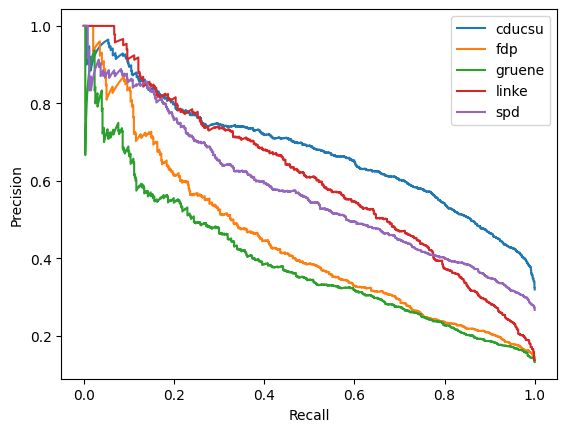

In [24]:
plot_pr(test_data, test_labels, clf)

### Confusion Matrix

Useful to understand what the model gets wrong. 

Shows the occurrences of predicted labels (rows) vs true-labels (columns)

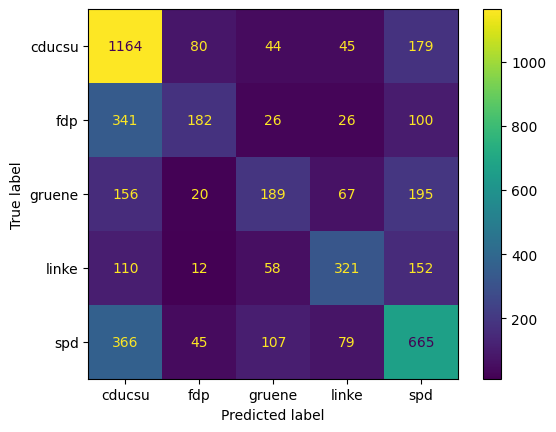

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_labels, test_predictions)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_).plot();


## XAI: What Has the Model Learned?

You can check the covariance of the data $X\in R^{D\times N}$ with the model's predictions $\hat{Y}\in R^{C\times N}$

$X\hat{Y}^\top$

where $D$ is the data dimensionality (here: number of words), $N$ is the number of data points , $C$ is the number of classes (here: parties) and $X$ and $\hat{Y}$ are normalized along the data axis.

[Haufe et al., *On the interpretation of weight vectors of linear models in multivariate neuroimaging.*, Neuroimage, 2014](https://www.ncbi.nlm.nih.gov/pubmed/24239590)

In [26]:
from sklearn.preprocessing import StandardScaler

def list_top_words_per_party(data, clf, top_words=5):
    idx_to_word = {idx:word for word, idx in clf.steps[0][1].vocabulary_.items()}
    ngram_features = StandardScaler().fit_transform(clf.steps[0][1].transform(data).toarray())
    scores = StandardScaler().fit_transform(clf.predict_proba(data))
    parties = clf.steps[1][1].classes_
    top_words_per_party = dict()
    for idx, party in enumerate(parties):
        covar = ngram_features.T @ scores[:,idx]
        top_word_idx = covar.argsort()[-top_words:]
        top_words_per_party[party] = [idx_to_word[idx] for idx in top_word_idx]
    return top_words_per_party
        
list_top_words_per_party(test_data[:1000], clf)

{'cducsu': ['diskussion', 'glaube', 'richtig', 'zukunft', 'christlich'],
 'fdp': ['freizügigkeit', 'christlich', 'liberalen', 'fdp', 'liberale'],
 'gruene': ['biologischen',
  'ökologisch',
  'steigende',
  'vertreterinnen',
  'bundesregierung'],
 'linke': ['skandal', 'sozialversicherungen', 'ausgrenzung', 'hartz', 'armut'],
 'spd': ['niebel', 'gemeint', 'finde', 'kanzlerin', 'fehlanzeige']}

## Cross-Validation For Model Evaluation

- ML models can memorize any data set (**overfitting**)
    
- But we want our models to perform well on new data (**generalization**)

- Cross-validation emulates the setting of new unseen data:

    - Split data in training and test
    - Train model on training set
    - Test model on test set
    
- K-Fold Cross-validation:

    - Split data in k non-overlapping folds
    - K Times:
        - Train on k-1 folds
        - Test on 1 remaining fold
        

### Most important ML lesson:

> **Never evaluate your ML model on the data used for training*!**


*(and model selection Hyperparameter Optimization counts as training, so you need another data set for that, which is called validation set)

### Controlling Model Complexity

![model_complexity](figures/overfitting_underfitting_cartoon.png)

- Penalization of model complexity in Machine Learning is called **Regularization**
- Regularization can be achieved by:
     - Choosing the right model (e.g. NCC or KNN)
     - Controlling Hyperparameters (e.g. k in KNN)
     - Changing preprocessing parameters

### Example: Overfitting with Preprocessing

In [27]:
num_word_params = [10, 100, 1000, 1e4, 1e5, 1e6]
acc_scores_train = []
acc_scores_test = []
for idx, n_words in enumerate(num_word_params):
    clf_tmp = train(train_data, train_labels, num_words=n_words)
    acc_scores_test.append(accuracy_score(test_labels, clf_tmp.predict(test_data)))
    acc_scores_train.append(accuracy_score(train_labels, clf_tmp.predict(train_data)))

Text(0, 0.5, 'Accuracy')

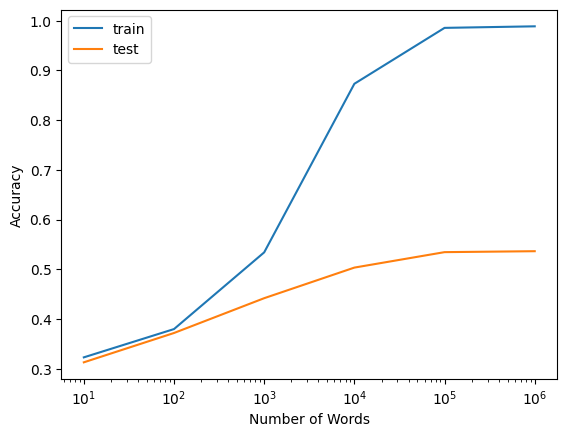

In [28]:
plt.plot(num_word_params, acc_scores_train)
plt.plot(num_word_params, acc_scores_test)
plt.xscale('log')
plt.legend(['train','test'])
plt.xlabel('Number of Words')
plt.ylabel('Accuracy')

### Hyperparameters

- For an end-to-end (raw data to final prediction) ML system, many hyperparameters need to be set


- Selecting the right hyperparameters is often crucial for successful predictions


- A hyperparameter (HP) is often defined as a parameter that cannot be estimated using gradient descent. 


- Examples:
    - number of words in a bag-of-words representation
    - number of categories (assuming that there are many rare ones)
    - $n$ in n-grams
    - normalization or not
    - learning rate in stochastic gradient descent
    - ...
    

    

### Hyperparameter Optimization / Model Selection


Hyperparameter optimization (HPO) requires yet another data split:
    
 - Either just train (for training) / validation  (for HPO) / test (for evaluation)
 - Or k-fold nested Cross-validation
     - Split data into k folds
     - K times:
         - Keep one fold aside for evaluation (**outer** cross-validation)
         - Run HPO with cross-validation on remaining k-1 folds using (**inner** cross-validation)
         
 - Nested Cross-validation is more expensive but gives you better hyperparameters as well as better generalization error estimates


### HPO Approaches

- Grid Search: Try all possible hyperparameter sets using nested cross validation


- Random Search: Try a number of random hyperparameter sets (works surprisingly well)


- Bayesian Global Optimization: Train a probabilistic model (e.g. Gaussian Processes) to predict model performance given hyperparameter settings

In [29]:

def train_hpo(texts, party, num_words=1e5):
    '''
    A function that takes trains a simple NLP text classification pipeline

    Input: 
        texts and labels and number of features

    Output: 
        trained pipeline
    
    '''
    
    text_clf = Pipeline([('vect', TfidfVectorizer(max_features=int(num_words))),
                            ('clf', SGDClassifier(loss='log_loss'))])

    # some hyperparameters
    parameters = {
        'vect__ngram_range': [(1, 1), (1, 2), (1, 3)],
        'clf__alpha': (np.logspace(-5, 2, 5)).tolist()
    }
    # perform gridsearch to get the best regularizer
    clf = GridSearchCV(text_clf, parameters, cv=2, n_jobs=-1,verbose=0)
    clf.fit(texts, party)

    return clf

In [ ]:
clf = train_hpo(train_data, train_labels)

In [45]:
print(classification_report(test_labels, clf.predict(test_data)))

              precision    recall  f1-score   support

      cducsu       0.62      0.83      0.71      1512
         fdp       0.63      0.28      0.39       675
      gruene       0.54      0.37      0.44       627
       linke       0.70      0.57      0.63       653
         spd       0.59      0.67      0.63      1262

    accuracy                           0.61      4729
   macro avg       0.61      0.54      0.56      4729
weighted avg       0.61      0.61      0.59      4729



## Cross-Validation

- Split dataset in training and test set
- Used for:
    - Model Evaluation
        - Requires **at least two** different folds / partitions / data sets (train and test)
    - Hyperparameter Optimization
        - Requires **at least three** different folds (train, validation and test)
- Fast Cross-validation:
    - Make two (or three) partitions, train (or validate and train) and test
- Cross-validation with best generalization performance estimates:
    - k-fold

### Simplest Cross-Validation for Model Evaluation

Split data into **two folds** and train / test **just once**

|$~$ |$~$|
|--|--|
|Fold 1|Test|
|Fold 2|Train|

### Example 3-Fold Cross-Validation for Model Evaluation:

Split data into three folds:

|$~$ |
|--|
|Fold 1|
|Fold 2|
|Fold 3|

#### Iteration 1

|$~$ |$~$|
|--|--|
|Fold 1|Test|
|Fold 2|Train|
|Fold 3|Train|

####  Iteration 2

|$~$ |$~$|
|--|--|
|Fold 1|Train|
|Fold 2|Test|
|Fold 3|Train|

####  Iteration 3

|$~$ |$~$|
|--|--|
|Fold 1|Train|
|Fold 2|Train|
|Fold 3|Test|

### Simplest Cross-Validation for Model Evaluation and Model Selection

* Split data into **three folds**
* Perform model selection on the train set using the validation set for computing the generalization performance
* After best hyperparameters are found, train on the training (and the validation) set
* Test the model on the test set. 

|$~$ |$~$|
|--|--|
|Fold 1|Test|
|Fold 2|Validation|
|Fold 3|Train|

### Example 3-Fold Nested Cross-Validation:

This performs an 

- **inner** cross-validation for **model selection** / hyperparameter optimization 

nested in an 

- **outer** cross-validation loop for **model evaluation**

Split data into three folds:

|$~$ |
|--|
|Fold 1|
|Fold 2|
|Fold 3|

#### Outer (Evaluation)  Iteration 1

Perform model selection on the train set using the validation set for computing the generalization performance.

##### Inner (Model Selection)  Iteration 1

|$~$|$~$|
|--|--|
|Fold 1|Test|
|Fold 2|Validation|
|Fold 3|Train|

##### Inner (Model Selection)  Iteration 2

|$~$|$~$|
|--|--|
|Fold 1|Test|
|Fold 2|Train|
|Fold 3|Validation|

#### Outer (Evaluation)  Iteration 2

Perform model selection on the train set using the validation set for computing the generalization performance.

##### Inner (Model Selection)  Iteration 1

|$~$|$~$|
|--|--|
|Fold 1|Validation|
|Fold 2|Test|
|Fold 3|Train|

##### Inner (Model Selection) Iteration 2

|$~$|$~$|
|--|--|
|Fold 1|Train|
|Fold 2|Test|
|Fold 3|Validation|

#### Outer (Evaluation)  Iteration 3

Perform model selection on the train set using the validation set for computing the generalization performance.

##### Inner (Model Selection) Iteration 1

|$~$|$~$|
|--|--|
|Fold 1|Train|
|Fold 2|Validation|
|Fold 3|Test|

##### Inner (Model Selection) Iteration 2

|$~$|$~$|
|--|--|
|Fold 1|Validation|
|Fold 2|Train|
|Fold 3|Test|

# AutoML 

Pipelines help to automate
     - Feature extraction
     - ML model selection
     - ML training
     - ML hyperparameter tuning



AutoML approaches leverages that (see e.g. [AutoML page by Hutter et al.](https://www.automl.org/automl/))

All you need is a data set and a target variable!

And the resulting models are much smaller/faster than LLMs ... 

## AutoML Example with Autogluon

Let's try AutoML on the Titanic example from the beginning. 

We'll follow the [Autogluon quickstart example](https://auto.gluon.ai/stable/tutorials/tabular/tabular-quick-start.html)

In [19]:
from autogluon.tabular import TabularPredictor

X_df, y_series = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True, parser="auto")
label = 'survived'
X_df[label] = y_series
X_train, X_test = train_test_split(X_df)
X_train.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
867,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,15,NaN,NaN,1
693,3,"Buckley, Mr. Daniel",male,21.0,0,0,330920,7.8208,NaN,Q,13,NaN,"Kingwilliamstown, Co Cork, Ireland New York, NY",1
1073,3,"O'Connor, Mr. Maurice",male,NaN,0,0,371060,7.7500,NaN,Q,NaN,NaN,NaN,0
330,2,"Ashby, Mr. John",male,57.0,0,0,244346,13.0000,NaN,S,NaN,NaN,"West Hoboken, NJ",0
1301,3,"Youseff, Mr. Gerious",male,45.5,0,0,2628,7.2250,NaN,C,NaN,312.0,NaN,0


In [20]:
predictor = TabularPredictor(label=label).fit(X_train)


No path specified. Models will be saved in: "AutogluonModels/ag-20250418_185245"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.9.18
Operating System:   Darwin
Platform Machine:   x86_64
Platform Version:   Darwin Kernel Version 23.6.0: Mon Jul 29 21:16:46 PDT 2024; root:xnu-10063.141.2~1/RELEASE_ARM64_T8112
CPU Count:          8
Memory Avail:       1.51 GB / 24.00 GB (6.3%)
Disk Space Avail:   549.97 GB / 1858.19 GB (29.6%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accurac

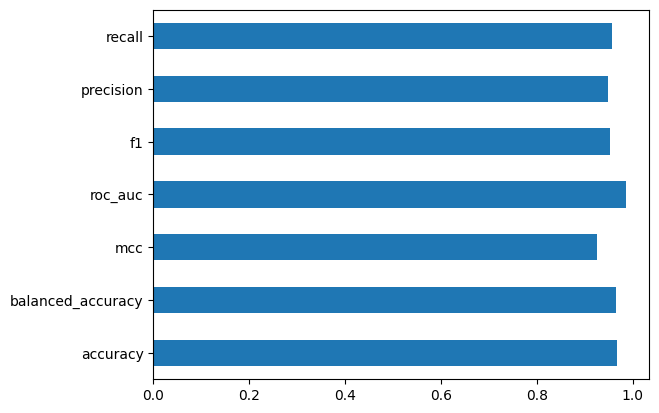

In [35]:
results = predictor.evaluate(X_test, silent=True)
pd.Series(results).plot.barh();

In [24]:
predictor.leaderboard(X_test)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetTorch,0.966463,0.989848,accuracy,0.009439,0.007608,3.127241,0.009439,0.007608,3.127241,1,True,7
1,WeightedEnsemble_L2,0.966463,0.989848,accuracy,0.010200,0.008241,3.148227,0.000761,0.000633,0.020986,2,True,8
2,RandomForestEntr,0.963415,0.964467,accuracy,0.037875,0.028015,0.315243,0.037875,0.028015,0.315243,1,True,4
3,RandomForestGini,0.963415,0.959391,accuracy,0.048934,0.029667,5.453009,0.048934,0.029667,5.453009,1,True,3
4,ExtraTreesEntr,0.957317,0.969543,accuracy,0.045483,0.028877,0.274196,0.045483,0.028877,0.274196,1,True,6
5,ExtraTreesGini,0.954268,0.964467,accuracy,0.038892,0.025051,0.275656,0.038892,0.025051,0.275656,1,True,5
6,KNeighborsDist,0.743902,0.746193,accuracy,0.005133,0.004160,0.006130,0.005133,0.004160,0.006130,1,True,2
7,KNeighborsUnif,0.731707,0.736041,accuracy,0.005980,3.839446,7.678851,0.005980,3.839446,7.678851,1,True,1


In [28]:
predictor.feature_importance(X_test)

Computing feature importance via permutation shuffling for 13 features using 328 rows with 5 shuffle sets...
	3.32s	= Expected runtime (0.66s per shuffle set)
	0.74s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
boat,0.368902,0.028681,0.000004,5,0.427957,0.309847
parch,0.010366,0.005943,0.008770,5,0.022603,-0.001871
sex,0.007317,0.006322,0.030406,5,0.020334,-0.005700
ticket,0.007317,0.001670,0.000304,5,0.010755,0.003879
pclass,0.003659,0.001363,0.001941,5,0.006466,0.000851
fare,0.002439,0.003975,0.120991,5,0.010624,-0.005746
body,0.002439,0.001363,0.008065,5,0.005246,-0.000368
home.dest,0.001220,0.004624,0.293525,5,0.010740,-0.008301
cabin,0.000610,0.002551,0.310654,5,0.005862,-0.004642
embarked,0.000610,0.001363,0.186950,5,0.003417,-0.002198


# Summary 

* AutoML leverages automation
* Classification metrics
  - Accuracy can be high for bad classifiers
  - Use Precision / Recall
 
* Other important evaluation dimensions (not covered)
  * Energy Efficiency (e.g. with [codecarbon](https://codecarbon.io))
  * [(Probabilistic) Calibration](https://scikit-learn.org/stable/auto_examples/calibration/plot_calibration_curve.html#probability-calibration-curves)
  * Robustness
  * Fairness (e.g. with [fairlearn](https://fairlearn.org))


# Appendix
## Testing Political Bias Model with User Input

In [33]:
text = "Neoliberale Heuschrecken Banker sind schlecht für den Sozialstaat."
clf.predict([text])

array(['linke'], dtype='<U6')

In [34]:
text = "Wachstum und Sicherheit sind wichtig für glückliche Familien"
clf.predict([text])

array(['cducsu'], dtype='<U6')

## Classification of Newspaper Articles

In [35]:
import newspaper

news_with_predictions = []
articles = newspaper.build("https://www.sueddeutsche.de/").articles

In [36]:
for article in articles:
    try:
        article.download()
        article.parse()
        news_with_predictions.append(
            {
                'title': article.title,
                'url': article.url,
                'text': article.text,
                'party_prediction': clf.predict([article.text]) 
            })
    except Exception as ex:
        pass

In [37]:
df_news = pd.DataFrame(news_with_predictions)
df_news

,title,url,text,party_prediction
0,Im Gerichtssaal mit Donald Trump,https://www.sueddeutsche.de/kultur/trump-vor-g...,Von Marie Pohl\n\nAm Montag wurde der Pressean...,[cducsu]
1,Gaza-Krieg: Israel muss Offensive in Rafah sto...,https://www.sueddeutsche.de/politik/rafah-offe...,Israel muss seine Offensive im Süden des Gazas...,[linke]
2,Heidelberg: Zwei junge Männer sollen Messeratt...,https://www.sueddeutsche.de/politik/anschlag-s...,In Heidelberg haben die Sicherheitsbehörden of...,[spd]
3,"Regisseur von ""Super Size Me"" ist tot",https://www.sueddeutsche.de/kultur/morgan-spur...,"Wie ergeht es einem, wenn man sich 30 Tage lan...",[gruene]
4,Barcelona trennt sich von Xavi und einigt sich...,https://www.sueddeutsche.de/sport/barcelona-tr...,"Hansi Flick, 59, steht unmittelbar vor einem E...",[cducsu]
...,...,...,...,...
407,"Business Data Platform & Governance (w/m/d), I...",https://stellenmarkt.sueddeutsche.de/job/it-bu...,Informationen zur Anzeige:\n\nAnzeigeninhalt:\...,[cducsu]
408,"Technischer Leiter (m/w/d), Dr. Lubos Kliniken...",https://stellenmarkt.sueddeutsche.de/job/techn...,Informationen zur Anzeige:\n\nAnzeigeninhalt:\...,[cducsu]
409,Sachbearbeiter in der Buchhaltung / Kreditoren...,https://stellenmarkt.sueddeutsche.de/job/sachb...,Informationen zur Anzeige:\n\nAnzeigeninhalt:\...,[cducsu]
410,"Leitung Operativer Einkauf (w/m/d), Dr. Lubos ...",https://stellenmarkt.sueddeutsche.de/job/leitu...,Informationen zur Anzeige:\n\nAnzeigeninhalt:\...,[cducsu]


Zeitungsartikel: Gaza-Krieg: Israel muss Offensive in Rafah stoppen


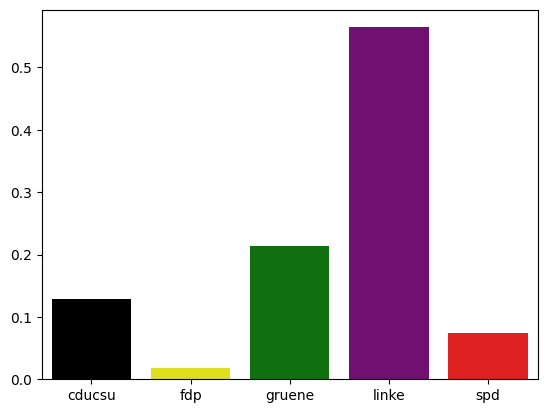

In [38]:
prediction = clf.predict_proba([df_news.loc[1,'text']])  


print("Zeitungsartikel: {}".format(df_news.loc[1,'title']))

import seaborn as sns
%matplotlib inline
sns.barplot(x=clf.best_estimator_.steps[1][1].classes_, y=prediction.flatten(), palette=[partei_farben[p] for p in clf.classes_]);

## Political Bias Prediction: ML Model vs Human Performance

In [39]:
# We draw 5 random speeches with less than 2000 characters, so it's still readable
samples = df[df.text.apply(len) < 1002].sample(5)
prediction_human = []
prediction_machine = clf.predict(samples.text)
true_party = samples.partei.tolist()

for idx, text in enumerate(samples.text):
    print("================================")
    print(text)
    print('------------------------------------')
    print("Which party does this speech belong to? Choose from {}".format(clf.classes_))
    prediction_human.append(input())
    print("*****************************")
    print("Your prediction: {}".format(prediction_human[-1]))
    print("ML prediction: {}".format(prediction_machine[idx]))
    print("True party: {}".format(true_party[idx]))
    print("================================")

Ich glaube, dass es auch ein Erfolg von vielen Abgeordneten der Unionsfraktion ist, die das genauso sehen wie wir; denn dieses Thema behandeln wir fraktionsübergreifend.

Der Rechtsausschuss hat ja gemeinsam eine Beschlussempfehlung gefasst, an der Vertreter aller Fraktionen – SPD, Grüne, Linke, CDU/CSU – beteiligt waren. Ich glaube, da haben wir als Parlamentarier zusammengestanden. Es geht auch darum, dass wir kein Präjudiz für die Zukunft schaffen, wodurch Mitbestimmung im Bundestag beschnitten wird. Wenn uns die Regierung jetzt mitteilt, dass wir das Vorhaben im Bundestag ratifizieren können, dann wird das Parlament sicherlich auch in Zukunft bei allen gemischten Freihandelsabkommen gemäß dem Grundgesetz entsprechende Rechte haben. Dafür werden uns vielleicht nachfolgende Kolleginnen und Kollegen noch sehr dankbar sein.

Deswegen ist klar, Kollege Kekeritz – ich habe es damals schon angekündigt –: Wir als SPD werden aufgrund des Regierungshandelns Ihren Antrag für erledigt erklären

 cducsu


*****************************
Your prediction: cducsu
ML prediction: cducsu
True party: spd
Ich war in diesem Jahr mit einigen Kollegen in Afghanistan und habe dort mit Soldaten gesprochen. Wir haben natürlich auch darüber gesprochen, wie die Perspektive sein wird, wenn wir ab 2011, 2012, wie es der Außenminister formuliert hat, damit beginnen, Verantwortung auf Afghanistan und die afghanischen Sicherheitseinrichtungen zu übertragen und Fähigkeiten abzuziehen, die wir dort nicht mehr brauchen. Ich war beeindruckt nicht nur von Offizieren und Generälen, sondern auch von ganz normalen Soldatinnen und Soldaten, die uns im Gespräch gesagt haben: Es darf nicht sein, dass unser Einsatz sinnlos war. Sinnlos wäre er gewesen - so haben sie formuliert -, wenn Afghanistan wieder in den Zustand käme, aus dem wir Afghanistan eigentlich befreien wollten. Das war eine beeindruckende Aussage unserer Soldatinnen und Soldaten. Daran müssen wir unseren Einsatz messen. Wir wollen, dass die Situation in Af

 gruene


*****************************
Your prediction: gruene
ML prediction: cducsu
True party: cducsu
Vielen Dank, Herr Staatsminister. - Ich gehe davon aus, dass die Bundeskanzlerin keine Referentenentwürfe in die Kabinettsberatungen einbringt. Es war aber die Bundeskanzlerin, die im Zusammenhang mit der Diskussion über Panzerlieferungen an Saudi-Arabien sehr konkret von der Gestaltungsmacht Saudi-Arabiens gesprochen hat. Deswegen verwundert es mich jetzt schon, dass Sie auf der einen Seite noch in einem offenen intellektuellen Findungsprozess mit aufstrebenden Mächten zur Gestaltung deutscher Globalisierungspolitik sind und auf der anderen Seite bereits Waffenlieferungen in den Nahen Osten genehmigt haben. Wie passt das zusammen? Wie bewerten Sie, wenn Saudi-Arabien zu den Gestaltungsmächten gehört, mit Blick auf die Waffenlieferungen an dieses Land eine Studie der Stiftung Wissenschaft und Politik - die Stiftung arbeitet sowohl der Bundesregierung als auch dem Bundestag zu; die Studie ist 

...

*****************************
Your prediction: gruene
ML prediction: spd
True party: spd
Wenn sich dann die Frau Bundeskanzlerin hier auch mit einem gewissen Pathos hinstellt und den Primat der Politik gegenüber Wirtschaft und Finanzindustrie unterstreicht, dann ist das doch - um den Begriff der Redlichkeit aufzugreifen - auch unredlich, weil diese Koalition, jedenfalls Teile davon, genau für das Gegenteil steht, die FDP sich weitgehend verweigert hat und Sie, Herr Schäuble, sich offensichtlich auch gegen Ihren eigenen Willen für die Finanztransaktionsteuer aussprechen mussten. Sie haben ja beim Wirtschaftsrat der CDU gesagt, dass das nicht Ihrer eigenen Überzeugung entsprechen würde. So wurden sie jedenfalls zitiert.

Was ist das für eine Politik, wenn sich die Regierungskoalition des größten Landes in Europa in zentralen Fragen, die darüber entscheiden, wie die nächste Krise, wenn sie denn kommt, zu bewältigen ist - sie soll ja durch Prävention verhindert werden -, so aufstellt, wie 

 cducsu


*****************************
Your prediction: cducsu
ML prediction: spd
True party: spd
Aber entscheidend ist dabei doch: Handelt es sich um eine Verabredung oder eine Verordnung? Deshalb finde ich andere Fragen viel entscheidender als die Frage der Sanktion.

Nehmen wir als erstes Beispiel einmal die Eingliederungsvereinbarung. Ich finde, eine Eingliederungsvereinbarung ist ein Schlüsselinstrument, um Menschen den Weg in den Arbeitsmarkt zu ebnen, und zwar dann, wenn eine echte Verständigung stattfindet, die den Wünschen der Arbeitsuchenden genauso gerecht wird wie sie den realistischen Möglichkeiten entspricht, und sich die Arbeitsuchenden mit ihr auch identifizieren können. Dann ist sie ein Erfolgsinstrument. Aber sind die Voraussetzungen dafür überall geschaffen? Lässt der Betreuungsschlüssel an allen Stellen eine so intensive Betreuung und Beratung zu, dass es wirklich klappt? Stimmt die Chemie zwischen den Beratern und denen, die Beratung wünschen? Was passiert, wenn das nicht d

 linke


*****************************
Your prediction: linke
ML prediction: spd
True party: spd


In [41]:
print("Your performance:")
print(classification_report(prediction_human, true_party))

print("ML model performance:")
print(classification_report(prediction_machine, true_party))

Your performance:
              precision    recall  f1-score   support

      cducsu       0.00      0.00      0.00       2.0
      gruene       0.00      0.00      0.00       2.0
       linke       0.00      0.00      0.00       1.0
         spd       0.00      0.00      0.00       0.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0

ML model performance:
              precision    recall  f1-score   support

      cducsu       1.00      0.50      0.67         2
         spd       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5

